In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET EVALUATION

In [2]:
df=pd.read_csv("../data/restu.csv")
#print(df.isnull().sum().sort_values(ascending=False))
#print(df['Is delivering now'].value_counts())
#print(df.shape)
#print(df.columns)
df=df.dropna()
#dropping unrequired cols
cols_to_drop=['Restaurant ID','Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose','Rating color', 'Rating text','Switch to order menu']
df=df.drop(columns = [c for c in cols_to_drop if c in df.columns])
print(df.columns)



Index(['Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')


ENCODING CATEGORICAL COLUMNS

In [3]:
le=LabelEncoder()
bin_col=['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in bin_col:
    df[col]=le.fit_transform(df[col])


MULTICOLLINEARITY

                feature       VIF
1           Price range  1.877894
3     Has Table booking  1.380226
4   Has Online delivery  1.307001
2                 Votes  1.243282
0  Average Cost for two  1.014399


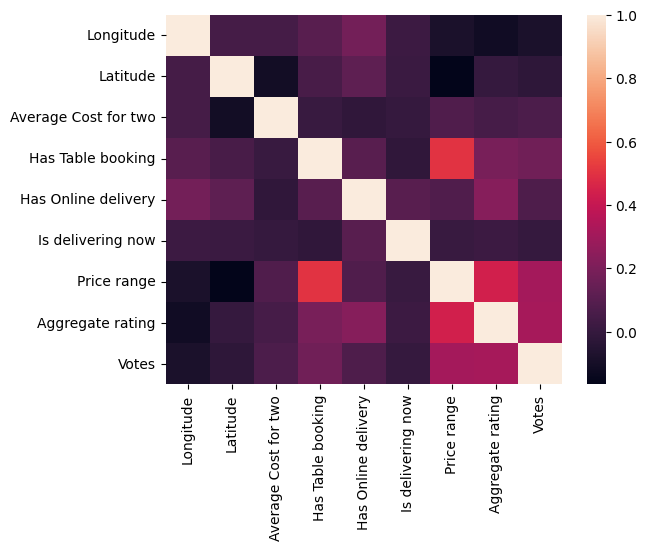

In [4]:
sns.heatmap(df.corr(numeric_only=True))
#plt.show()
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Properly slice the dataframe with numeric columns
xvif = df[['Average Cost for two', 'Price range', 'Votes', 'Has Table booking', 'Has Online delivery']]

# 2. Initialize the DataFrame correctly with ()
vif_data = pd.DataFrame()
vif_data['feature'] = xvif.columns

# 3. Calculate VIF (ensure xvif.values is used)
vif_data['VIF'] = [variance_inflation_factor(xvif.values, i) for i in range(len(xvif.columns))]

print(vif_data.sort_values(by='VIF', ascending=False))



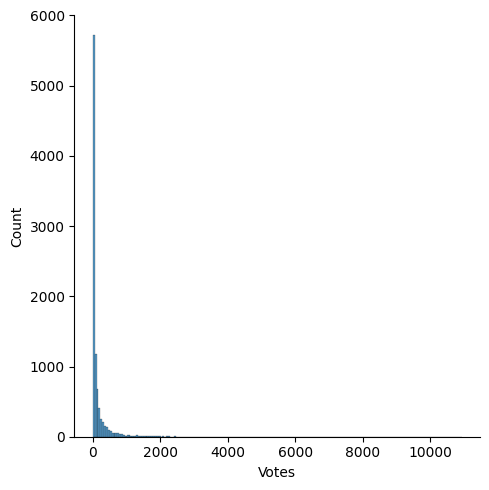

In [5]:
sns.displot(df['Votes'])
plt.show()

FEATURE EXTRACTION

In [6]:
exchange_rates = {
    'Indian Rupees(Rs.)': 0.012,
    'Dollar($)': 1.0,
    'Pounds()': 1.27,
    'Brazilian Real(R$)': 0.20,
    'Emirati Diram(AED)': 0.27,
    'Rand(R)': 0.053,
    'NewZealand($)': 0.61,
    'Turkish Lira(TL)': 0.031,
    'Botswana Pula(P)': 0.073,
    'Indonesian Rupiah(IDR)': 0.000064,
    'Qatari Rial(QR)': 0.27,
    'Sri Lankan Rupee(LKR)': 0.0033
}


df['Cost_USD'] = df.apply(lambda x: x['Average Cost for two'] * exchange_rates.get(x['Currency'], 1), axis=1)


df['Cuisine_Count'] = df['Cuisines'].apply(lambda x: len(str(x).split(',')))
df['Log_Votes'] = np.log1p(df['Votes']) 
df=df.drop(columns=['Average Cost for two','Currency','Votes','Cuisines'])
print(df.columns)

x=df.drop('Aggregate rating',axis=1)
y=df['Aggregate rating']




Index(['Longitude', 'Latitude', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Aggregate rating', 'Cost_USD',
       'Cuisine_Count', 'Log_Votes'],
      dtype='object')


Index(['Longitude', 'Latitude', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Cost_USD', 'Cuisine_Count',
       'Log_Votes'],
      dtype='object')


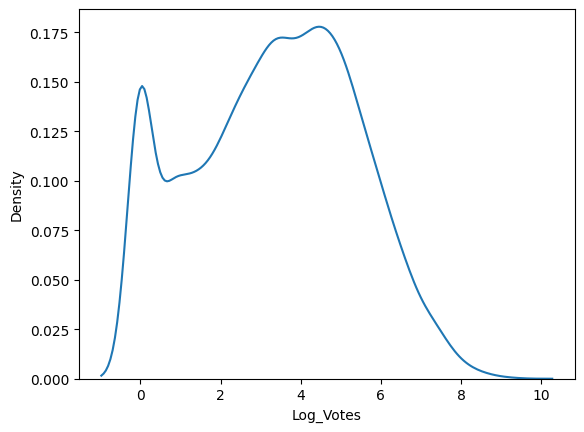

In [7]:
print(x.columns)
sns.kdeplot(x['Log_Votes'])
plt.show()

HANDLING OUTLIERS

In [8]:
def handle_outliers(df,columns):
    for col in columns:
        q1=x[col].quantile(0.25)
        q3=x[col].quantile(0.75)
        iqr=q3-q1
        lower=q1-1.5*iqr
        upper=q3+1.5*iqr
        x[col]=np.clip(x[col],lower,upper)
    return x
numeric_cols=['Price range', 'Cost_USD', 'Cuisine_Count',
       'Log_Votes']
xl=handle_outliers(x.copy(),numeric_cols)
print(xl.columns)

Index(['Longitude', 'Latitude', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Price range', 'Cost_USD', 'Cuisine_Count',
       'Log_Votes'],
      dtype='object')


LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xl=scaler.fit_transform(xl)

X_train, X_test, y_train, y_test = train_test_split(xl, y, test_size=0.2, random_state=42)

def objective(trial):
    # Hyperparameters to tune
    alpha = trial.suggest_float('alpha', 1e-5, 10.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
    
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    
    # Using cross-validation for a more robust score
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-score.mean())
    
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Best parameters: {study.best_params}")

[I 2026-03-22 10:05:14,086] A new study created in memory with name: no-name-66695707-61cd-4ae0-a888-a845061d5f40
[I 2026-03-22 10:05:17,508] Trial 0 finished with value: 0.7998990073269298 and parameters: {'alpha': 0.001154328686098061, 'l1_ratio': 0.16035027932894008}. Best is trial 0 with value: 0.7998990073269298.
[I 2026-03-22 10:05:20,283] Trial 1 finished with value: 0.7999025330863442 and parameters: {'alpha': 6.689782180128381e-05, 'l1_ratio': 0.9736823835138924}. Best is trial 0 with value: 0.7998990073269298.
[I 2026-03-22 10:05:22,320] Trial 2 finished with value: 0.7998733175491334 and parameters: {'alpha': 0.004110415461427364, 'l1_ratio': 0.3776382629950177}. Best is trial 2 with value: 0.7998733175491334.
[I 2026-03-22 10:05:22,355] Trial 3 finished with value: 0.8054981499396318 and parameters: {'alpha': 0.05935795348570313, 'l1_ratio': 0.951637701903152}. Best is trial 2 with value: 0.7998733175491334.
[I 2026-03-22 10:05:22,384] Trial 4 finished with value: 0.7998993

Best parameters: {'alpha': 0.004650921779616655, 'l1_ratio': 0.6691964107383411}


In [10]:
best_params=study.best_params
final_lr=ElasticNet(**best_params)
final_lr.fit(X_train,y_train)
ypred=final_lr.predict(X_test)
print(f"MAE,{mean_absolute_error(y_test,ypred):.4f}")
print(f'RMSE {np.sqrt(mean_squared_error(y_test,ypred)):.4f}')
print(f'R2{r2_score(y_test,ypred)}')

MAE,0.6823
RMSE 0.7979
R20.7219649786869884


SVM REGRESSOR

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hyperparameters to tune
    c = trial.suggest_float('C', 0.1, 100, log=True)
    epsilon = trial.suggest_float('epsilon', 0.01, 1.0, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel = trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
    
    # Initialize SVR with suggested parameters
    model = SVR(C=c, epsilon=epsilon, kernel=kernel, gamma=gamma)
    
    # 5-Fold Cross Validation
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-score.mean())
    
    return rmse

# Create and run the study
study_svr = optuna.create_study(direction='minimize')
study_svr.optimize(objective, n_trials=50)

print(f"Best SVR Parameters: {study_svr.best_params}")

[I 2026-03-22 10:05:23,660] A new study created in memory with name: no-name-bd25d635-9053-4506-9d37-971ba153d181
[I 2026-03-22 10:05:26,025] Trial 0 finished with value: 7.633716921736697 and parameters: {'C': 0.1271743716150196, 'epsilon': 0.28850286735559905, 'gamma': 'auto', 'kernel': 'sigmoid'}. Best is trial 0 with value: 7.633716921736697.
[I 2026-03-22 10:05:28,248] Trial 1 finished with value: 0.6117860462378307 and parameters: {'C': 0.29533053068242326, 'epsilon': 0.013542788301663923, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 1 with value: 0.6117860462378307.
[I 2026-03-22 10:05:40,855] Trial 2 finished with value: 1.4658027453578246 and parameters: {'C': 7.494747550005281, 'epsilon': 0.014239418738424225, 'gamma': 'scale', 'kernel': 'poly'}. Best is trial 1 with value: 0.6117860462378307.
[I 2026-03-22 10:05:43,275] Trial 3 finished with value: 5106.69743392299 and parameters: {'C': 84.68275608556326, 'epsilon': 0.4424640770117328, 'gamma': 'scale', 'kernel': 'sigmoi

In [ ]:

best_svr = study_svr.best_params

final_svr = SVR(**best_svr)
final_svr.fit(X_train, y_train)

y_pred_svr = final_svr.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_svr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_svr)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_svr):.4f}")


MAE: 0.3628
RMSE: 0.5092
R2 Score: 0.8868


LGB

In [ ]:
import lightgbm as lgb

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='neg_mean_squared_error')
    return np.sqrt(-score.mean())

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=50)

[I 2026-03-22 09:17:29,247] A new study created in memory with name: no-name-48549453-d38c-426e-b203-5c0044a9233b
[I 2026-03-22 09:17:36,789] Trial 0 finished with value: 0.32073567676821996 and parameters: {'n_estimators': 741, 'learning_rate': 0.15126735321003396, 'num_leaves': 572, 'max_depth': 6, 'min_child_samples': 97}. Best is trial 0 with value: 0.32073567676821996.
[I 2026-03-22 09:17:48,816] Trial 1 finished with value: 0.3143520615088756 and parameters: {'n_estimators': 472, 'learning_rate': 0.014074175568085106, 'num_leaves': 2351, 'max_depth': 10, 'min_child_samples': 47}. Best is trial 1 with value: 0.3143520615088756.
[I 2026-03-22 09:18:02,945] Trial 2 finished with value: 0.33306388638818907 and parameters: {'n_estimators': 716, 'learning_rate': 0.06381879535281626, 'num_leaves': 1635, 'max_depth': 11, 'min_child_samples': 16}. Best is trial 1 with value: 0.3143520615088756.
[I 2026-03-22 09:18:05,922] Trial 3 finished with value: 0.33042961833606443 and parameters: {'

In [ ]:
best_lgb=study_lgb.best_params
lgb_model=lgb.LGBMRegressor(**best_lgb)
lgb_model.fit(X_train,y_train)

y_pred_lgb = lgb_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_lgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lgb):.4f}")



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 842
[LightGBM] [Info] Number of data points in the train set: 7633, number of used features: 8
[LightGBM] [Info] Start training from score 2.667889
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


XGBOOST

In [ ]:
import xgboost as xgb

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42
    }
    
    model = xgb.XGBRegressor(**params)
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='neg_mean_squared_error')
    return np.sqrt(-score.mean())

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)

[I 2026-03-22 09:21:54,818] A new study created in memory with name: no-name-b883c585-db1f-4f58-b642-185a072697fe
[I 2026-03-22 09:21:55,814] Trial 0 finished with value: 0.31461766610567127 and parameters: {'n_estimators': 955, 'max_depth': 4, 'learning_rate': 0.040623038706287515, 'subsample': 0.8886695573806911, 'colsample_bytree': 0.9371976575104568}. Best is trial 0 with value: 0.31461766610567127.
[I 2026-03-22 09:21:56,657] Trial 1 finished with value: 0.31897326291026706 and parameters: {'n_estimators': 372, 'max_depth': 7, 'learning_rate': 0.03714509855968826, 'subsample': 0.6825444691202738, 'colsample_bytree': 0.6538859642117938}. Best is trial 0 with value: 0.31461766610567127.
[I 2026-03-22 09:21:57,344] Trial 2 finished with value: 0.3325667086991243 and parameters: {'n_estimators': 296, 'max_depth': 7, 'learning_rate': 0.11168914655684968, 'subsample': 0.6794361038811063, 'colsample_bytree': 0.5364722555482567}. Best is trial 0 with value: 0.31461766610567127.
[I 2026-03

In [ ]:
best_xgb=study_xgb.best_params
xgb_model=lgb.LGBMRegressor(**best_xgb)
xgb_model.fit(X_train,y_train)

y_pred_xgb= xgb_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 845
[LightGBM] [Info] Number of data points in the train set: 7633, number of used features: 9
[LightGBM] [Info] Start training from score 2.667889
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


TESTING PERFORMANCE

In [ ]:
print("TRAIN",final_lr.score(X_train,y_train))
print("Yest",final_lr.score(X_test,y_test))

scores_lr=cross_val_score(final_lr,xl,y,cv=5,scoring='r2')
print(scores_lr.mean())

TRAIN 0.7227891733600122
Yest 0.7219263412864885
0.6958947620547595


In [ ]:
print("TRAIN",final_svr.score(X_train,y_train))
print("Yest",final_svr.score(X_test,y_test))

scores_svr=cross_val_score(final_svr,xl,y,cv=5,scoring='r2')
print(scores_svr.mean())

TRAIN 0.8981808604879238
Yest 0.8867824491451205
0.8475255995690004


In [ ]:
print("TRAIN",lgb_model.score(X_train,y_train))
print("Yest",lgb_model.score(X_test,y_test))

scores_lgb=cross_val_score(lgb_model,xl,y,cv=5,scoring='r2')
print(scores_lgb.mean())

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


TRAIN 0.9654894805010248
Yest 0.9596948823554404
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 7633, number of used features: 8
[LightGBM] [Info] Start training from score 2.527158
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


STACKING

In [ ]:
from sklearn.ensemble import StackingRegressor
estimators = [
    ("svm", final_svr),
    ("xgb", xgb_model),
    ("lgbm", lgb_model)
]
# Stacking model
stack = StackingRegressor(
    estimators=estimators,
    final_estimator=final_lr,
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

pred = stack.predict(X_test)

from sklearn.metrics import r2_score
print("Stack R2:", r2_score(y_test, pred))

Stack R2: 0.959809317659179


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
